In [29]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/airbnb_data.csv")
df.head(1)

/var/folders/ky/twz1wh510q938k2krxzw5lv00000gn/T/ipykernel_15609/3555813467.py:6: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/airbnb_data.csv")


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN


In [30]:
df["price"] = df["price"].str.replace(r'[$,]', '', regex=True).astype(float)

df["price"]

0          966.0
1          142.0
2          620.0
3          368.0
4          204.0
           ...  
102594     844.0
102595     837.0
102596     988.0
102597     546.0
102598    1032.0
Name: price, Length: 102599, dtype: float64

In [31]:
df = df.dropna(subset=["price", "reviews per month"])

In [32]:
r, p = stats.pearsonr(df["price"], df["reviews per month"])
r2 = r ** 2
print(f"r: {r:.4f}, p: {p:.4f}, r2: {r2:.4f}")

r: 0.0042, p: 0.2183, r2: 0.0000


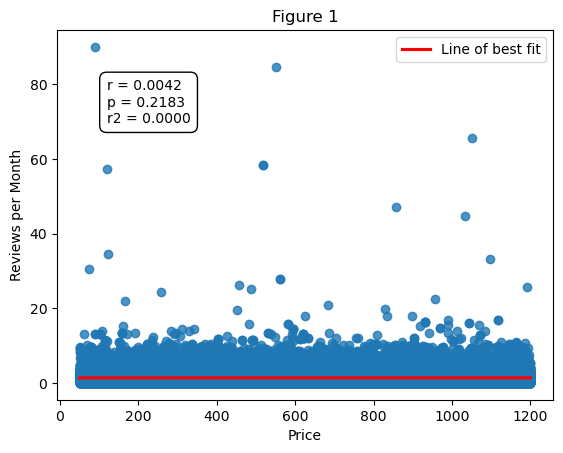

In [35]:
scat = sns.regplot(data = df, x = "price", y = "reviews per month", line_kws = {"color": "red", "label": "Line of best fit"})
scat.set(xlabel = "Price", ylabel = "Reviews per Month", title = "Figure 1")
text = f"""r = {r:.4f}
p = {p:.4f}
r2 = {r2:.4f}"""
scat.text(
    0.1,
    0.75,
    text,
    transform = scat.transAxes,
    bbox = {"boxstyle": "round, pad = 0.5", "fc": "white"}
)
plt.legend()

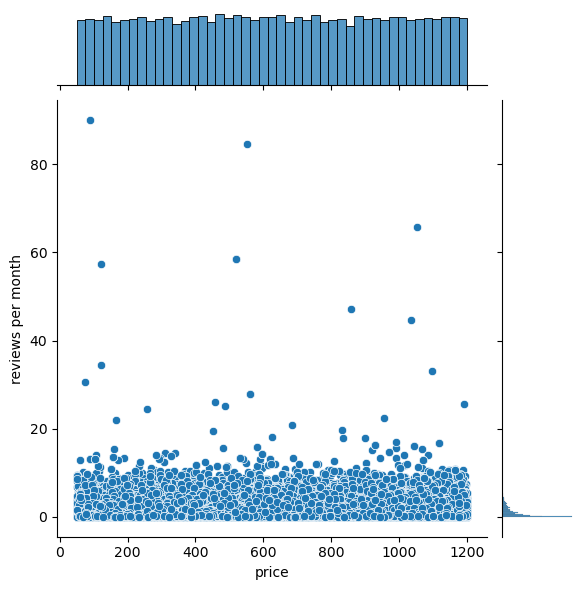

In [36]:
sns.jointplot(data = df, x = "price", y = "reviews per month")